## Ejercicio 2 - Convolución con deltas

Se tiene la respuesta al impulso:

h[n] = δ[n] − δ[n−4]

De acuerdo a lo visto en clase, la convolución con deltas produce corrimientos de la señal.

En particular:

y[n] = x[n] * h[n] = x[n] − x[n−4]

Es decir, la salida es la diferencia entre la señal original y una versión desplazada 4 muestras.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# eje discreto
n = np.arange(-10, 20)

### Definición de h[n]

Se construye la secuencia utilizando deltas discretos.

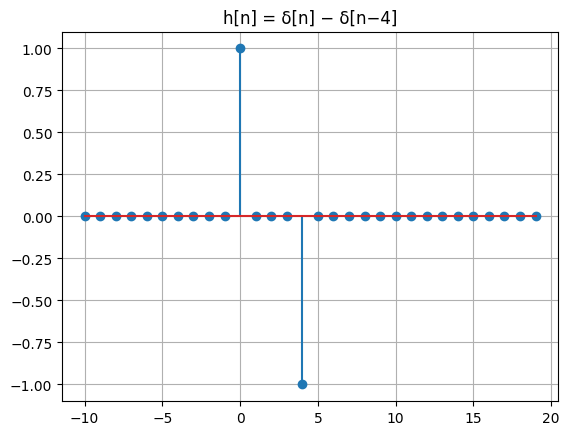

In [2]:
h = np.zeros_like(n)

h[n == 0] = 1
h[n == 4] = -1

plt.stem(n, h)
plt.title("h[n] = δ[n] − δ[n−4]")
plt.grid()

### Inciso a)

x[n] = cos(ω₀ n Ts)

Se calcula la salida utilizando la propiedad de corrimiento.

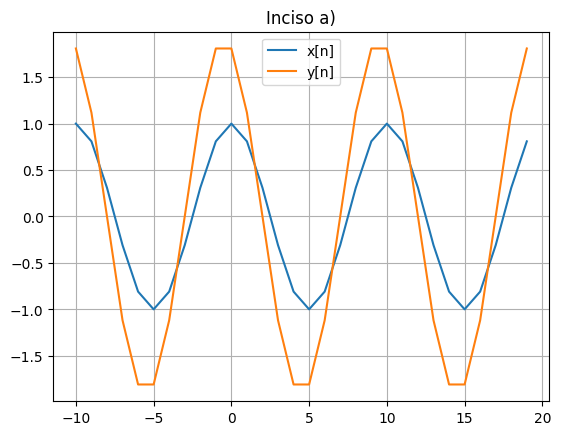

In [3]:
w0 = 0.2 * np.pi
Ts = 1

x = np.cos(w0 * n * Ts)

# implementación directa
y = x - np.roll(x, 4)

plt.figure()
plt.plot(n, x, label="x[n]")
plt.plot(n, y, label="y[n]")
plt.legend()
plt.title("Inciso a)")
plt.grid()

Verificación mediante convolución numérica:

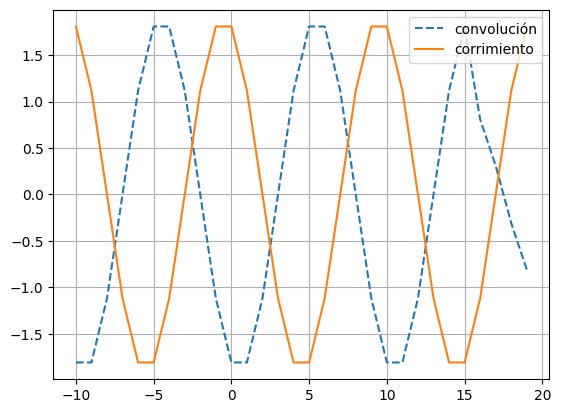

In [4]:
y_conv = np.convolve(x, h, mode='same')

plt.figure()
plt.plot(n, y_conv, '--', label="convolución")
plt.plot(n, y, label="corrimiento")
plt.legend()
plt.grid()

### Inciso b)

x[n] = (1/2)^n u[n]

Se define la función escalón unitario y se aplica la misma propiedad.

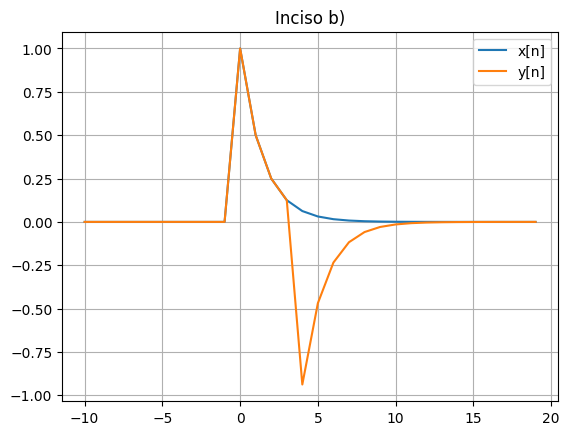

In [5]:
u = np.where(n >= 0, 1, 0)

x = (0.5)**n * u

y = x - np.roll(x, 4)

plt.figure()
plt.plot(n, x, label="x[n]")
plt.plot(n, y, label="y[n]")
plt.legend()
plt.title("Inciso b)")
plt.grid()

### Inciso c)

x[n] = u[n+1] − u[n−2]

Se construyen los escalones desplazados y se calcula la salida.


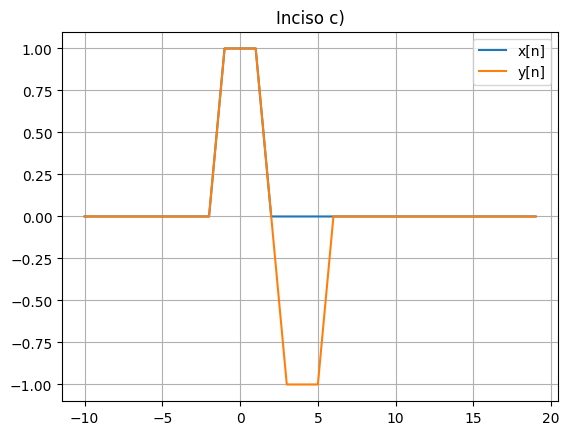

In [6]:
u1 = np.where(n+1 >= 0, 1, 0)
u2 = np.where(n-2 >= 0, 1, 0)

x = u1 - u2

y = x - np.roll(x, 4)

plt.figure()
plt.plot(n, x, label="x[n]")
plt.plot(n, y, label="y[n]")
plt.legend()
plt.title("Inciso c)")
plt.grid()

## Conclusión

Se verificó que la convolución con deltas desplazados produce corrimientos en la señal.

En este caso, la salida resulta de restar la señal original con una versión desplazada 4 muestras, lo cual coincide con la teoría vista en clase.